# Digital Signals Theory

In [1]:
%matplotlib inline

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import soundfile as sf

from IPython.display import display, Audio

## Chapter 9: The Short-time Fourier Transform

For the example graphs in Chapter 9, the book uses a mono version of [SLIDE WHISTLE - 1](https://freesound.org/people/SamuelGremaud/sounds/517633/), the sound of slide whistle (up and down) shared & produced by freesound.org user SamuelGremaud.

In [2]:
wav = "bin/517633__samuelgremaud__slide-whistle-1.wav"

In [3]:
file_info = sf.info(wav)
file_info

bin/517633__samuelgremaud__slide-whistle-1.wav
samplerate: 48000 Hz
channels: 2
duration: 6.205 s
format: WAV (Microsoft) [WAV]
subtype: Signed 24 bit PCM [PCM_24]

In [4]:
stereo_x, fs = sf.read(wav)
mono_x = stereo_x[:,0]/2 + stereo_x[:,1]/2

display('Sound of slide whistle, up and down (mono)')
display(Audio(data=mono_x, rate=fs))

'Sound of slide whistle, up and down (mono)'

----

### 9.2 Defining the STFT

#### 9.2.1 A basic STFT algorithm

Given the differences in various implementations of STFT such as [`scipy.signal.stft`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.stft.html#stft) and [`librosa.stft`](https://librosa.org/doc/0.11.0/generated/librosa.stft.html#librosa-stft), it looks like the book opts implement a naive implementation from scratch. Of course, this really goes a long way in cementing your basic understanding of what happens in STFT.

For the curious, you may want to be aware of the [Difference between librosa.stft and scipy.signal.stft](https://dsp.stackexchange.com/questions/71410/difference-between-librosa-stft-and-scipy-signal-stft). In a nutshell, `scipy.signal.stft` apparently scales the results by a normalization factor of $\frac{1}{sum(windowing)}$, while `librosa.stft` doesn't.


In [5]:
def basic_stft(x, n_frame, n_hop):
    '''Compute a basic Short-Time Fourier transform
    of a real-valued input signal.'''
    
    # Compute the number of frames
    frame_count = 1 + (len(x) - n_frame) // n_hop
    
    # Initialize the output array
    # We have frame_count frames 
    #     and (1 + n_frame//2) frequencies for each frame
    stft = np.zeros((frame_count, 1 + n_frame // 2), dtype=np.complex128)
    
    # Populate each frame's DFT results
    for k in range(frame_count):
        # Slice the k'th frame
        x_frame = x[k * n_hop:k * n_hop + n_frame]
        
        # Take the DFT (non-negative frequencies only)
        stft[k, :] = np.fft.rfft(x_frame)
        
    return stft

#### 9.2.2 Spectrograms

Per the caption for Figure 9.3 on page 127, we set:

* $N_{F} = 1024$
* $N_{H} = 512$

In [6]:
N_F = 1024
N_H = 512

In [7]:
X = basic_stft(mono_x, N_F, N_H)

NOTE: the return value from `basic_stft` has shape (total number of frames in STFT, number of positive frequencies obtained via `numpy.fft.rff`).

Before plotting, we need to compute 

* `times` ... series of starting times for each frame in our STFT; recall that each frame has time interval length of $\frac{N_{H}}{f_{s}}$ in units of `[samples]/[samples/sec]` seconds.

In [8]:
times = np.arange(X.shape[0]) * N_H / fs
#times[:5]

* `freqs` ... series of frequency bin centers for use with `numpy.fft.rfft` (in units of `[samples/sec]` in our example); recall that each sample in a signal sampled at $f_{s}$ is `[sample]/[samples/sec]` seconds

c.f. API documentation for [`numpy.fft.rfftfreq`](https://numpy.org/doc/stable/reference/generated/numpy.fft.rfftfreq.html#numpy-fft-rfftfreq)

In [9]:
freqs = np.fft.rfftfreq(N_F, 1/fs)

Rather than use [`librosa.diplay.specshow`](), the book opts to use [`matplotlib.pyplot.pcolormesh`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pcolormesh.html#matplotlib-pyplot-pcolormesh) for the spectrogram plotting.

* _Linear magnitude scaling_ simply uses `numpy.abs` on each frame's (R)FFT, note that due to the implementation of `basic_stft` above, we need to use the transpose.
* _Decibel scaling_ uses the modified calculation as given on p. 172

\begin{flalign}
\qquad S_{dB}  &= 20 \cdot \log_{10} \left( \frac{S}{\sqrt{N_{F}}} + 10^{-4} \right) & \\\\
\end{flalign}

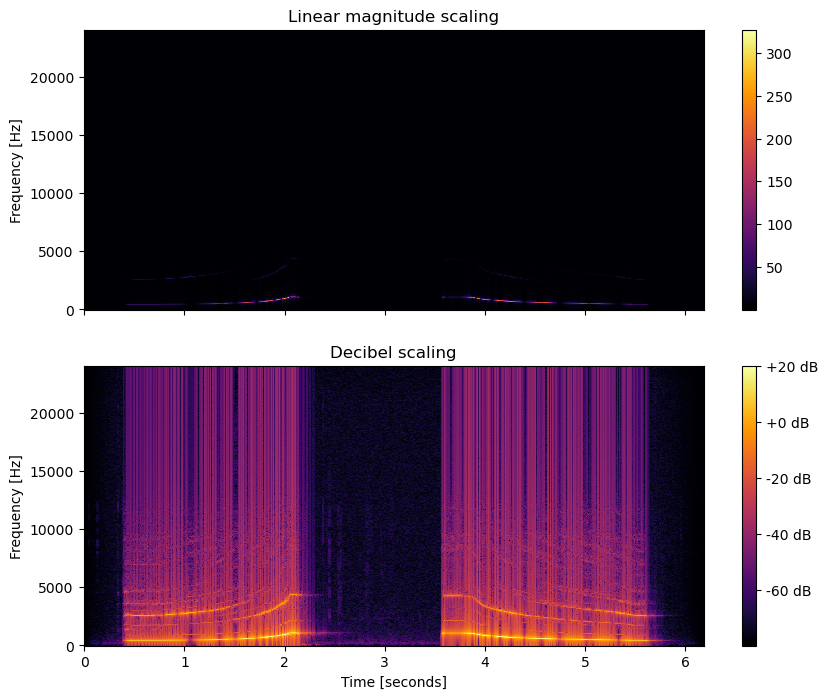

In [10]:
fig, (ax0, ax) = plt.subplots(nrows=2, sharex=True, sharey=True, figsize=(10,8))

img = ax0.pcolormesh(times, freqs, np.abs(X.T), shading='nearest', rasterized=True, cmap='inferno')
ax0.grid(False)
ax0.set(
    title='Linear magnitude scaling',
    xlabel='Time [seconds]', 
    ylabel='Frequency [Hz]'
)
ax0.label_outer()
ax0.set_title('Linear magnitude scaling')

fig.colorbar(img, ax=[ax0])

spec_db = 20 * np.log10(np.abs(X)/np.sqrt(N_F) + 1e-4)
imgdb = ax.pcolormesh(times, freqs, spec_db.T, shading='nearest', rasterized=True, cmap='inferno')
ax.grid(False)
ax.set(
    title='Decibel scaling',
    xlabel='Time [seconds]', 
    ylabel='Frequency [Hz]'
)
fig.colorbar(imgdb, format='%+2.0f dB', ax=[ax])

plt.show()

<span style="background-color:#3FF;">... so since human perception of amplitude is _logarthmic_ and _not linear_, we should use decibel scaling when looking at spectral graphs.</span>

#### 9.2.3 Choosing parameters

##### Frame length $N_{F}$

Notice how the STFT lets us control the number of samples per frame via frame length $N_{F}$. This leads to the **time-frequency trade-off**, where a larger frame length better frequency resolution at the cost of reduced time resolution. In other words, when $N_{F}$ is a large we can better see the frequencies in a frame, but we will know less about when exactly those frequencies occcur (all we know is that those frequencies affected the signal during frame in question.

In order to leverage radix-2 based Fast Fourier transforms, $N_{F}$ is chosen to be a power of 2.

Additionally...

> ... one heuristic for choosing frame length is to ensure that it is long enough to observe at least a few cycles at the low end of the audible frequency range (which have the longest periods $t_{0} = \frac{1}{f_{s}}$).

Knowing that 20 Hz is the lowest frequency humans can generally perceive, assuming sampling frequency $f_{s} = \text{48000 Hz}$ and all things being equal, you might wish to calculate frame length $N_{F}$

\begin{flalign}
\qquad \text{20 Hz} & \rightarrow  \frac{1}{20} = \text{0.1 sec} & \\\\
\qquad \text{if } N_{F}  &= 4096  & \\\\
\qquad \text{then } \frac{N_{F}}{f_{s}}  &= \frac{4096}{48000} \approx 0.085  & \\\\
\end{flalign}

In [11]:
# let N_F vary; keep N_H and f_s fixed
lengths = [32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]
check = {}
for n_f in lengths:
    _X = basic_stft(mono_x, n_f, N_H)
    _spec_db = 20 * np.log10(np.abs(_X)/np.sqrt(n_f) + 1e-4)
    check[n_f] = {
        'times': np.arange(_X.shape[0]) * N_H / fs,
        'freqs': np.fft.rfftfreq(n_f, 1/fs),
        'spec_db': _spec_db
    }

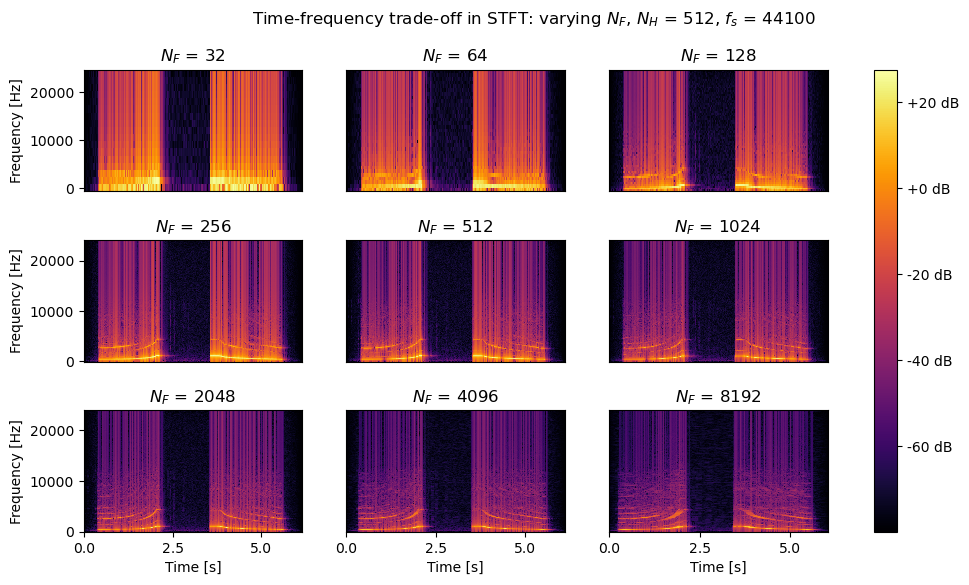

In [12]:
fig, axes = plt.subplots(nrows=3, ncols=3, sharex=False, sharey=False, figsize=(12,6))

for i, _row in enumerate(axes):
    for j, _ax in enumerate(_row):
        # calculate the correct index in lengths array...
        li = i*3 + j
        k = lengths[li]
        items = check[k]
    
        imgdb = _ax.pcolormesh(
            items['times'], 
            items['freqs'], 
            items['spec_db'].T, 
            shading='nearest', rasterized=True, cmap='inferno'
        )
        _ax.grid(False)
        _ax.set(
            title='$N_F$ = '+ f'{k}'
        )
        # show the X-axis ticks and labels only for the last row!
        if li < 6:
            _ax.set_xticks([])
        else:
            _ax.set_xticks([0.0, 2.5, 5.0])
            _ax.set_xlabel('Time [s]')
        # show the Y-axis ticks and labels only for the first column!
        if li % 3 == 0:
            _ax.set_yticks([0, 10000, 20000])
            _ax.set_ylabel('Frequency [Hz]')
        else:
            _ax.set_yticks([])
            _ax.set_ylabel(None)

#plt.tight_layout()
plt.subplots_adjust(hspace=0.4)
plt.colorbar(imgdb, format='%+2.0f dB', ax=axes)
plt.suptitle("Time-frequency trade-off in STFT: varying $N_F$, $N_H$ = 512, $f_s$ = 44100")
plt.show()

<span style="background-color:#3FF;">... so in our example wave of that slide whistle, we might opt for a frame length of $N_{F}$ = 4096 samples.</span>

##### Hop length $N_{H}$

Note that if $N_{H} \gt N_{F}$ (in other words, we hop by _more than frame length_), then some samples will be passed over. Convention is to set $N_{H}$ to some constant fraction of $N_{F}$ like $\frac{1}{8}$, $\frac{1}{4}$, or $\frac{1}{2}$.

In [13]:
# let N_H vary; keep N_F and f_s fixed
N_F_fixed = 4096
lengths = [32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]
check = {}
for n_h in lengths:
    _X = basic_stft(mono_x, N_F_fixed, n_h)    
    _spec_db = 20 * np.log10(np.abs(_X)/np.sqrt(N_F_fixed) + 1e-4)
    check[n_h] = {
        'times': np.arange(_X.shape[0]) * n_h / fs,
        'freqs': np.fft.rfftfreq(N_F_fixed, 1/fs),
        'spec_db': _spec_db
    }

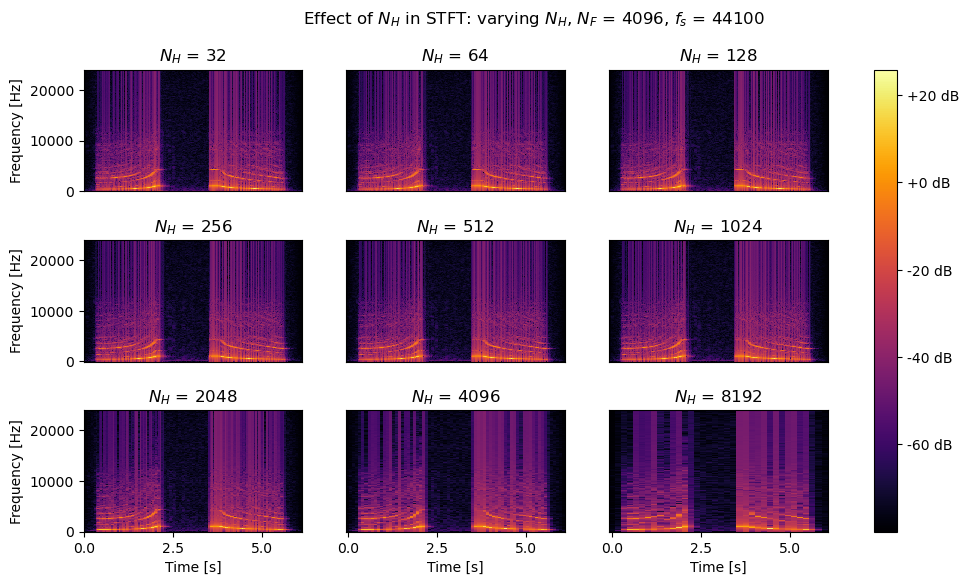

In [14]:
fig, axes = plt.subplots(nrows=3, ncols=3, sharex=False, sharey=False, figsize=(12,6))

for i, _row in enumerate(axes):
    for j, _ax in enumerate(_row):
        # calculate the correct index in lengths array...
        li = i*3 + j
        k = lengths[li]
        items = check[k]
    
        imgdb = _ax.pcolormesh(
            items['times'], 
            items['freqs'], 
            items['spec_db'].T, 
            shading='nearest', rasterized=True, cmap='inferno'
        )
        _ax.grid(False)
        _ax.set(
            title='$N_H$ = '+ f'{k}'
        )
        # show the X-axis ticks and labels only for the last row!
        if li < 6:
            _ax.set_xticks([])
        else:
            _ax.set_xticks([0.0, 2.5, 5.0])
            _ax.set_xlabel('Time [s]')
        # show the Y-axis ticks and labels only for the first column!
        if li % 3 == 0:
            _ax.set_yticks([0, 10000, 20000])
            _ax.set_ylabel('Frequency [Hz]')
        else:
            _ax.set_yticks([])
            _ax.set_ylabel(None)

#plt.tight_layout()
plt.subplots_adjust(hspace=0.4)
plt.colorbar(imgdb, format='%+2.0f dB', ax=axes)
plt.suptitle("Effect of $N_H$ in STFT: varying $N_H$, $N_F$ = 4096, $f_s$ = 44100")
plt.show()

<span style="background-color:#3FF;">... so, again with our example wave of that slide whistle and keeping $N_F$ = 4096 and $f_s$ = 48000, we might opt for $N_{H}$ = $\frac{N_F}{4}$ = 1024.</span>

##### Zero-padding the final frame

Even still, there may be a number of samples left out of the STFT. Consider the case where after creating the final frame of length $N_{F}$, we shift $N_{H}$ and from that point, there are not enough samples remaining (remainder $\lt N_{F}$). In such a case, pad this last frame with enough zeroes to reach $N_{F}$ samples for this final frame.

Say we have the following:

\begin{flalign}
\qquad N    &= 32 & \\
\qquad N_F  &= 10 & \\
\qquad N_H  &= 5 & \\
\end{flalign}

From equation 9.1 (page 169), we know the total number of possible frames before any sort of zero-padding can be calculate with:

\begin{flalign}
\qquad K &= 1 + \biggl\lfloor \dfrac{N - N_F}{N_H} \biggr\rfloor & \\
\qquad      &= 5 & \\
\end{flalign}

But that final frame index 4 ranges from :
\begin{flalign}
\qquad \text{start } &= N_H \cdot 4 = 20 & \\\\
\qquad \text{end }   &= N_H \cdot 4 + N_F - 1 = 29 & \\\\
\end{flalign}

... and that means this 32-sample long signal's indices 30 and 31 are left out. In order to include them, we need to zero-pad a 6th frame (index 5) so that
\begin{flalign}
\qquad \text{start } &= N_H \cdot 5 = 25 & \\\\
\qquad \text{end }   &= N_H \cdot 5 + N_F - 1 = 34 & \\\\
\end{flalign}

Thus, to calculate how many zeroes to append to the end of the _real, $K^{th}$_ final frame:

\begin{flalign}
\qquad \text{zero-padding } &= \left( N_H \cdot K + N_F \right) - N & \\\\
\end{flalign}

##### How about for our example slide whistle signal using $N_F$ = 4096 and $N_H$ = 1024?


In [15]:
N = int(file_info.samplerate * file_info.duration)

K = 1 + (N - 4096) // 1024

zeros = ((1024 * K) + 4096) - N

print(f"Looks like we need an extra {zeros} zeros to that {K}th frame")

Looks like we need an extra 156 zeros to that 287th frame


<span style="background-color:#3FF;">... padding the final frame with enough zeros to cover the entire sample span of our signal ensures we do not lose any information.</span>

#### 9.2.4 Windowing

The vertical band artifacts in spectrograms may be evidence of 
> ... broad-band bursts of energy across the entire frequency spectrum ... <br/>
> ... which are typically associated with transient events ... <br/>
> ... percussion or other abrupt discontinuities ...

But our example of the up-down whistle with a continuously varying pitch does not contain such transient events.

In STFT, it is very unlikely that a period signal will cleanly line up with the edge of a frame with length $N_{F}$. We know that in DFT, all available analysis frequencies will get used in order to explain/describe abrupt discontinuities from the signal segment in a frame being looped infinitely: this is **spectral leakage**.  This is the cause of those vertical banding artifacts in STFT.

This spectral leakage can be be mitigated by windowing, which is a sample-wise multiplication of the signal segment in a frame with a curve that tapers to 0 at the ends. This tapering off to 0 (apodiation) at the beginning and ending of the window curve will smooth out the signal segment in a frame so that if it were infinitely looped, it would appear continuous instead of with abrupt cut-off points.

In [16]:
def windowing_stft(x, n_frame, n_hop, window):
    '''Compute a windowed Short-Time Fourier transform
    
    Parameters
    ----------
    x : the input signal (real-valued)
    
    n_frame : the frame length (in samples)
    
    n_hop : the hop length (in samples)
    
    window : a window specification
        e.g., "hann" or ("kaiser", 4.0)
        
        See scipy.signal.get_window for details
        
    Returns
    -------
    stft : the Short-Time fourier transform of x (complex-valued)
        Shape: (frame_count, 1 + n_hop // 2)
    '''
    
    # Compute the number of frames
    frame_count = 1 + (len(x) - n_frame) // n_hop
    
    # Initialize the output array
    # We have frame_count frames and (1 + n_frame//2) frequencies for each frame
    X = np.zeros((frame_count, 1 + n_frame // 2), dtype=np.complex128)
    
    # We'll use scipy's window constructor here
    window = sp.signal.get_window(window, n_frame)
    
    # Populate each frame's DFT results
    for k in range(frame_count):
        # Slice the k'th frame, apply a window, and take its DFT
        X[k, :] = np.fft.rfft(x[k * n_hop:k * n_hop + n_frame] * window)
        
    return X

In [17]:
# example using a Hann window
_N_F = 4096
_N_H = 1024


X_nowindowing = basic_stft(mono_x, _N_F, _N_H)    
spec_db_nowindowing = 20 * np.log10(np.abs(X_nowindowing)/np.sqrt(_N_F) + 1e-4)

times = np.arange(X_nowindowing.shape[0]) * _N_H / fs
freqs = np.fft.rfftfreq(_N_F, 1/fs)

X_hann =  windowing_stft(mono_x, _N_F, _N_H, 'hann')
spec_db_hann = 20 * np.log10(np.abs(X_hann)/np.sqrt(_N_F) + 1e-4)

X_hamming = windowing_stft(mono_x, _N_F, _N_H, 'hamming')
spec_db_hamming = 20 * np.log10(np.abs(X_hamming)/np.sqrt(_N_F) + 1e-4)

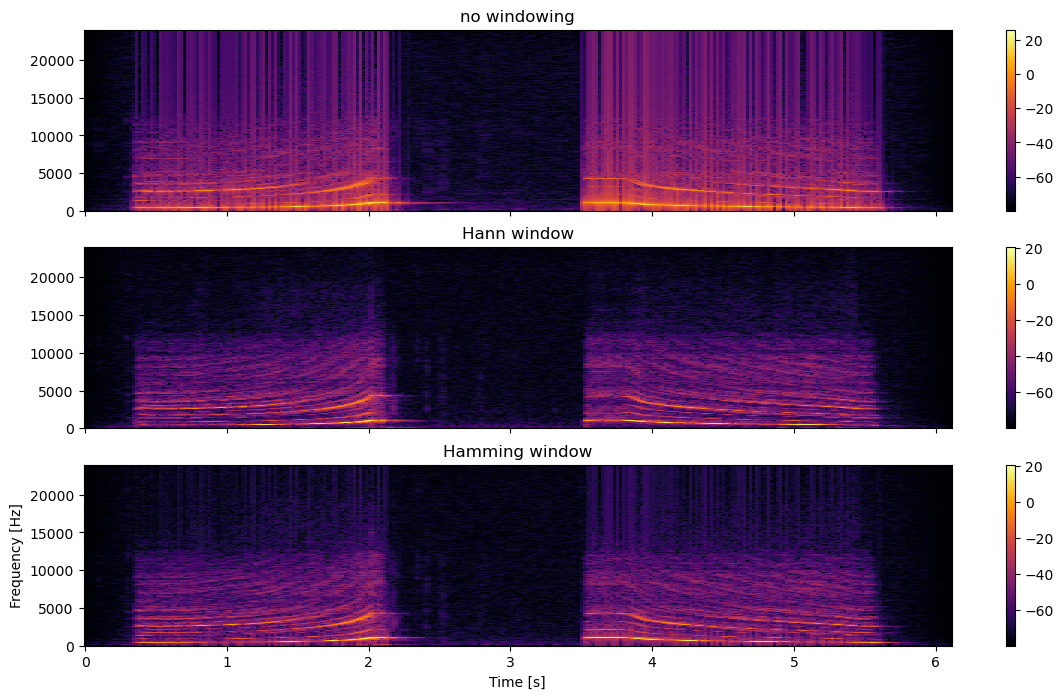

In [18]:
fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, ncols=1, sharex=True, sharey=False, figsize=(14,8))

img = ax0.pcolormesh(times, freqs, spec_db_nowindowing.T, shading='nearest', rasterized=True, cmap='inferno')
ax0.grid(False)
ax0.set(
    title='no windowing',
)
ax0.label_outer()
fig.colorbar(img, ax=[ax0])

img = ax1.pcolormesh(times, freqs, spec_db_hann.T, shading='nearest', rasterized=True, cmap='inferno')
ax1.grid(False)
ax1.set(
    title='Hann window',
)
ax1.label_outer()
fig.colorbar(img, ax=[ax1])

img = ax2.pcolormesh(times, freqs, spec_db_hamming.T, shading='nearest', rasterized=True, cmap='inferno')
ax2.grid(False)
ax2.set(
    title='Hamming window',
    ylabel='Frequency [Hz]',
    xlabel='Time [s]'
)
ax2.label_outer()
fig.colorbar(img, ax=[ax2])

plt.show()

<span style="background-color:#3FF;">... with our example slide whistle signal, since the image sort of looks crisper than both without windowing and with a Hamming window, I suppose we'd go with a Hann window?</span>

----

### 9.3 Exercises

#### Exercise 9.1

Given a signal and the following STFT parameters:


\begin{flalign}
\qquad N   &= 44100 & \\
\qquad f_s &= 44100 \text{ Hz } & \\
\qquad N_F &= 4096 & \\
\qquad N_H &= 512 & \\\\
\end{flalign}


_How many frames would result for the STFT in this case?_

From equation 9.1:

\begin{flalign}
\qquad K &= 1 + \biggl\lfloor \dfrac{44100 - 4096}{512} \biggr\rfloor & \\
\qquad      &= 1 + 78 & \\
\qquad      &= 79 \text{ frames} & \\
\end{flalign}



----

#### Exercise 9.2

_... Using the configurations listed in Ex. 9.1 above, what is the smallest amount of zeroes to pad that ensures **all** samples of the signal are included in STFT?_

_Give a more general form for calculating the required padding in terms of parameters $N$, $N_F$, $N_H$._

This has been worked out earlier in this notebook:

\begin{flalign}
\qquad \text{zero-padding } &= \left( N_H \cdot K + N_F \right) - N & \\\\
\qquad                      &= \left( N_H \cdot \left( 1 + \biggl\lfloor \dfrac{N - N_F}{N_H} \biggr\rfloor \right) + N_F \right) - N & \\\\
\qquad                      &= \left( 512 \cdot \left( 79 \right) + 4096 \right) - 44100 & \\\\
\qquad                      &= 444 \text{ zeroes should be padded} & \\\\
\end{flalign}

----

#### Exercise 9.3

> Using a (non-trivial) test signal $x$ of your choice, can you find parameter settings of [`scipy.signal.stft`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.stft.html#stft) that produce identical output to `windowing_stft`?

We will assume:

\begin{flalign}
\qquad N_F &= 2048 & \\
\qquad N_H &= 512  & \\
\end{flalign}

We will use the **Hann** windowing function.

In [19]:
_N_F = 2048
_N_H = 512
_windowing_type = 'hann'

##### Our test signal $x$

For our test signal, we will use Timbre's [remix of Benboncan__Sad_Trombone_more_wah_bright&de-clicked.wav](https://freesound.org/people/Timbre/sounds/73750/) from freesound.org.

In [20]:
wav = "bin/73750__timbre__remix-of-benboncan__sad_trombone_more_wah_brightde-clicked.wav"

In [21]:
file_info = sf.info(wav)
file_info

bin/73750__timbre__remix-of-benboncan__sad_trombone_more_wah_brightde-clicked.wav
samplerate: 44100 Hz
channels: 2
duration: 3.862 s
format: WAV (Microsoft) [WAV]
subtype: Signed 16 bit PCM [PCM_16]

In [22]:
stereo_x, fs = sf.read(wav)
mono_x = stereo_x[:,0]/2 + stereo_x[:,1]/2

display('a sad trombone (mono)')
display(Audio(data=mono_x, rate=fs))

'a sad trombone (mono)'

In [23]:
print(f"(raw) signal length? {int(file_info.samplerate * file_info.duration)}")
print()

N = int(file_info.samplerate * file_info.duration)
print(f"K w/out padding? {1 + (N - _N_F)//_N_H}")

(raw) signal length? 170304

K w/out padding? 329


<hr width=40%/>

##### STFT via `scipy.signal.stft`

From the [API documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.stft.html#stft), the return is a tuple of:
1. `f : ndarray` ...  Array of sample frequencies.
2. `t : ndarray` ... Array of segment times.
3. `Zxx : ndarray` ... STFT of `x`. By default, the last axis of `Zxx` corresponds to the segment times.

##### N.B.
* the return from `scipy.signal.stft` is scaled once with $scale = \frac{1}{win.sum()^2}$ (c.f. [line 2088 in `scipy/signal/_spectral_py.py`](https://github.com/scipy/scipy/blob/e29dcb65a2040f04819b426a04b60d44a8f69c04/scipy/signal/_spectral_py.py#L2088))
* ... and in `stft` mode, it is further scaled by taking the square root so that $scale = \sqrt{scale}$ (c.f. [line 2093 in the same](https://github.com/scipy/scipy/blob/e29dcb65a2040f04819b426a04b60d44a8f69c04/scipy/signal/_spectral_py.py#L2093))
* as our naive implementation in `windowing_stft` does no such thing, we will need to rescale the return value from `scipy.signal.stft` with a correction in order to make a valid comparison.

In [24]:
s1 = sp.signal.stft(
    mono_x,
    fs=fs,
    window=_windowing_type,
    nperseg=_N_F,
    noverlap=_N_F - _N_H,
    padded=None,
    boundary=None
)

#print(f"??? type(s1) is {type(s1)}")
#
#print(f"    s1[0].shape = {s1[0].shape}")
#print(f"    s1[1].shape = {s1[1].shape}")
#print(f"    s1[2].shape = {s1[2].shape}")

In [25]:
# calculate the scaling correction
_window = sp.signal.get_window(_windowing_type, _N_F)
scaling_correction = _window.sum()

In [26]:
s2 =  windowing_stft(
    mono_x,
    _N_F, 
    _N_H, 
    'hann'
)

#print(f"??? type(s2) is {type(s2)}")

#print(f"    s2.shape = {s2.shape}")

In [27]:
# idiot-check: are the shapes of the return values correct?

print(f"s1[2].shape = {s1[2].shape}")
print(f"s2.shape = {s2.shape}")

s1[2].shape = (1025, 329)
s2.shape = (329, 1025)


In [28]:
np.allclose( 
    s1[2] * scaling_correction, 
    s2.T
)

True

<span style="background-color:#3FF;">... the important arguments to `scipy.signal.stft` are:</span>

* `fs` ... set this to the sampling frequency of the signal in question
* `window` ... specify the windowing function
* `nperseg` ... specify the length of the frame (`scipy.signal.stft` documentation uses the term _segment_
* `noverlap` ... this "Number of points to overlap between segments" is $N_F - N_H$
* `padded` ... our `windowing_stft` does not do padding, so set this to `None`
* `boundary` ... our `windowing_stft` does not extend the signal in either direction, so set this to `None` as well

----

#### Exercise 9.3, EXTRA CREDIT

It turns out the `scipy.signal.stft` **is legacy**, and [`scipy.signal.ShortTimeFFT`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.ShortTimeFFT.html#shorttimefft) is the preferred API. Please see the Legacy note in the documentation for [`scipy.signal.stft`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.stft.html#stft).


The legacy [`scipy.signal.stft`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.stft.html#stft) has the following defaults:
* `window='hann'`
* `return_onesided=True`
* `boundary='zeros'`
* `padded=True`
* `scaling='spectrum'`

In [29]:
from scipy.fft import fftshift

# Legacy STFT:
f0_u, t0, Sz0_u = sp.signal.stft(
    mono_x,
    fs=fs,
    window=_windowing_type,
    nperseg=_N_F,
    noverlap=_N_F - _N_H,
    return_onesided=False, 
    scaling='spectrum'
)

f0, Sz0 = fftshift(f0_u), fftshift(Sz0_u, axes=0)

In [30]:
from scipy.signal import ShortTimeFFT

# New STFT:
SFT = ShortTimeFFT.from_window(
    _windowing_type, 
    fs, 
    nperseg=_N_F,
    noverlap=_N_F - _N_H,
    fft_mode='centered',
    scale_to='magnitude', 
    phase_shift=None
)

Sz1 = SFT.stft(mono_x)

In [31]:
print(f"Sz0.shape: {Sz0.shape}")
print()
print(f"Sz1.shape: {Sz1.shape}")

Sz0.shape: (2048, 334)

Sz1.shape: (2048, 336)


In [32]:
print(f"SFT.lower_border_end: {SFT.lower_border_end}")
print(f"SFT.upper_border_begin: {SFT.upper_border_begin(len(mono_x))}")

SFT.lower_border_end: (1537, 2)
SFT.upper_border_begin: (168448, 331)


In [33]:
np.allclose(Sz0, Sz1[:, SFT.lower_border_end[1]-1:-1])

True